<style>
    :root {
        --accent: #38bdf8;
        --bg-dark: #0f172a;
    }
    .jp-Notebook { background-color: var(--bg-dark) !important; color: #e2e8f0 !important; }
    .jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2 { color: var(--accent) !important; border-bottom: 1px solid rgba(56, 189, 248, 0.2) !important; }
    .insight-card {
        background: rgba(56, 189, 248, 0.05);
        border-left: 4px solid var(--accent);
        padding: 1.2rem;
        border-radius: 8px;
        margin: 1rem 0;
    }
    .status-tag {
        background: var(--accent);
        color: var(--bg-dark);
        padding: 2px 8px;
        border-radius: 4px;
        font-weight: bold;
        font-size: 0.8em;
    }
</style>

# 🔬 Intel Core Ultra NPU: Unified GNN Benchmarking Suite

<span class="status-tag">ADVANCED ANALYTICS MODE</span>

This notebook provides a complete research pipeline with time-synchronized energy correlation for each model architecture.

In [10]:
import os, sys, json, shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown, HTML

RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
FIGURES_DIR = Path("paper/figures")

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")
print("✅ Advanced Analytics Ready.")

✅ Advanced Analytics Ready.


### 📦 Step 1: Model Suite Generation
GNN + baseline (CNN/NLP) models; standardized and quantized.

In [ ]:
import sys
!{sys.executable} analysis/model_prep.py

Exporting GCN to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\models\GCN_fp32.onnx...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Done.
Quantizing GCN_fp32.onnx to INT8...
Statistics collection ---------------------------   0% 0/50 • 0:00:00 • -:--:--
Statistics collection  --------------------------   2% 1/50 • 0:00:00 • -:--:--
Statistics collection  --------------------------   2% 1/50 • 0:00:00 • -:--:--
Statistics collection - -------------------------   6% 3/50 • 0:00:00 • 0:00:04
Statistics collection -- ------------------------  10% 5/50 • 0:00:00 • 0:00:04
Statistics collection 

W0501 22:00:56.825000 5872 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0501 22:00:56.828000 5872 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0501 22:00:56.828000 5872 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
c:\Users\yusuf\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W0501 22:01:11.514000 5872 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0501 22:01:11.514000 5872 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_alig

### 📈 Step 2: Scalability & Timing Study
Executing models while recording high-precision start/end timestamps for energy correlation.

In [14]:
import sys
!{sys.executable} analysis/scalability_analyzer.py --iterations 100 --repeats 3 --profile

Found existing scalability_matrix.csv with 16 models; will skip and append missing.
Processing model: mobilenetv2_int8.onnx
Processing model: mobilenetv2_int8.ort_broken.onnx
  -> Skipping model mobilenetv2_int8.ort_broken.onnx due to error: [ONNXRuntimeError] : 1 : FAIL : This is an invalid model. Error: the graph is not acyclic.
Processing model: resnet50_int8.onnx
Processing model: resnet50_int8.ort_broken.onnx
  -> Skipping model resnet50_int8.ort_broken.onnx due to error: [ONNXRuntimeError] : 1 : FAIL : This is an invalid model. Error: the graph is not acyclic.
  -> Exported profiling trace for [resnet50_int8] (Baseline) to results/
  -> Exported profiling trace for [resnet50_int8] (Optimized) to results/


### 🔍 Step 3: Operator Profiling
Deep-dive into graph fusion and bottleneck identification.

In [ ]:
import sys
!{sys.executable} analysis/profiling_analyzer.py


RESEARCH METRICS SUMMARY
----------------------------------------
Fusion Gain Ratio (FGR): 0.9985
Compilation Efficiency Index (CEI): 0.0000
NPU Support Ratio (Optimized): 33.1%
Baseline Latency: 149.75 ms
Optimized Latency: 149.97 ms
Latency Reduction: 0.00 ms

Detailed analysis saved to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results


### 💻 Step 4: Hardware Comparison
Benchmarking all models across CPU, GPU, and NPU.

In [ ]:
import glob
import sys
from pathlib import Path

# Choose mode: "quick" or "full"
RUN_MODE = "full"

# Discover available FP32 models from disk (case-insensitive safe)
model_paths = [Path(p) for p in sorted(glob.glob("models/*_fp32.onnx"))]
found = {p.name.lower() for p in model_paths}

if RUN_MODE == "quick":
    iterations = 10
    repeats = 1
    allowlist = {
        "gcn_fp32.onnx",
        "graphsage_fp32.onnx",
        "resnet50_fp32.onnx",
    }
else:
    # Use these as defaults; increase for paper-grade numbers
    iterations = 30
    repeats = 1
    allowlist = None  # run all discovered FP32 models

if allowlist:
    missing = sorted(name for name in allowlist if name not in found)
    if missing:
        print(f"⚠️ Missing models: {', '.join(missing)}")

for model_path in model_paths:
    if allowlist and model_path.name.lower() not in allowlist:
        continue
    print(f"🚀 Device Comparison: {model_path}")
    !{sys.executable} analysis/hw_comparison.py --model {model_path} --iterations {iterations} --repeats {repeats}

⚠️ Missing models: bert-tiny_fp32.onnx
🚀 Device Comparison: models\APPNP_fp32.onnx
[22:18:09] Starting 3-way hardware comparison for: APPNP_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[22:18:09] Testing device: CPU...
  -> Repeat 1/1...
[22:18:12] Device CPU completed (1 runs) in 3.02 seconds.
[22:18:12] Testing device: GPU...
  -> Repeat 1/1...
[22:18:17] Device GPU completed (1 runs) in 4.97 seconds.
[22:18:17] Testing device: NPU...
  -> Repeat 1/1...
[22:18:19] Device NPU completed (1 runs) in 2.05 seconds.
[22:18:19] Hardware comparison complete.
Total time: 10.30 seconds.
Results saved in: C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results\hw_comparison\APPNP_fp32
🚀 Device Comparison: models\GAT_fp32.onnx
[22:18:32] Starting 3-way hardware comparison for: GAT_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[22:18:32] Testing device: CPU...
  -> Repeat 1/1...
[22:18:36] Device CPU completed (1 runs) in 3.65 seconds.
[22:18:36] Testing device: GPU...

 [ 0 ; 9 3 m 2 0 2 6 - 0 5 - 0 1   2 2 : 4 0 : 3 4 . 0 8 8 7 9 4 1   [ W : o n n x r u n t i m e : D e f a u l t ,   b a s i c _ b a c k e n d . c c : 1 2 3   o n n x r u n t i m e : : o p e n v i n o _ e p : : B a s i c B a c k e n d : : B a s i c B a c k e n d ]   M o d e l   c o m p i l a t i o n   f a i l e d   a t   O V   N P U . F a l l i n g   b a c k   t o   O V   C P U   f o r   e x e c u t i o n  [ m 
  [ 0 ; 9 3 m 2 0 2 6 - 0 5 - 0 1   2 2 : 4 0 : 3 5 . 9 2 2 0 4 3 9   [ W : o n n x r u n t i m e : D e f a u l t ,   b a s i c _ b a c k e n d . c c : 1 2 3   o n n x r u n t i m e : : o p e n v i n o _ e p : : B a s i c B a c k e n d : : B a s i c B a c k e n d ]   M o d e l   c o m p i l a t i o n   f a i l e d   a t   O V   N P U . F a l l i n g   b a c k   t o   O V   C P U   f o r   e x e c u t i o n  [ m 
 


[22:40:50] Starting 3-way hardware comparison for: GraphTransformer_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[22:40:50] Testing device: CPU...
  -> Repeat 1/1...
[22:40:53] Device CPU completed (1 runs) in 2.90 seconds.
[22:40:53] Testing device: GPU...
  -> Repeat 1/1...
[22:40:56] Device GPU completed (1 runs) in 3.54 seconds.
[22:40:56] Testing device: NPU...
  -> Repeat 1/1...
[22:40:58] Device NPU completed (1 runs) in 1.94 seconds.
[22:40:58] Hardware comparison complete.
Total time: 8.74 seconds.
Results saved in: C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results\hw_comparison\GraphTransformer_fp32
🚀 Device Comparison: models\SGC_fp32.onnx
[22:41:09] Starting 3-way hardware comparison for: SGC_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[22:41:09] Testing device: CPU...
  -> Repeat 1/1...
[22:41:17] Device CPU completed (1 runs) in 7.47 seconds.
[22:41:17] Testing device: GPU...
  -> Repeat 1/1...
[22:42:09] Device GPU completed (1 runs) i

In [15]:
from pathlib import Path
import pandas as pd
import onnx
from onnx import checker

# Verify models and outputs (derived from what exists on disk)
models_dir = Path("models")
results_dir = Path("results")
hw_dir = results_dir / "hw_comparison"

active_models = sorted(p for p in models_dir.glob("*.onnx") if not p.name.endswith(".ort_broken.onnx"))
if not active_models:
    print("❌ No models found under models/. Run Step 1 first.")
else:
    print(f"✅ Active models found: {len(active_models)}")

# Validate ONNX models (catch the common INT8-CNN invalid graph issue)
bad = []
for p in active_models:
    try:
        checker.check_model(onnx.load(str(p)))
    except Exception as e:
        bad.append((p.name, str(e)))
if bad:
    print("❌ Invalid ONNX models detected:")
    for name, msg in bad:
        print(f"  - {name}: {msg[:200]}")
else:
    print("✅ All active ONNX models pass onnx.checker.")

# Expect a hw_comparison output directory per FP32 model stem
fp32_models = sorted(p for p in models_dir.glob("*_fp32.onnx"))
expected_hw = sorted(p.stem.lower() for p in fp32_models)
found_hw = {p.name.lower() for p in hw_dir.iterdir() if p.is_dir()} if hw_dir.exists() else set()
missing_hw = sorted(name for name in expected_hw if name not in found_hw)
if missing_hw:
    print("❌ Missing hw_comparison outputs:", ", ".join(missing_hw))
else:
    print("✅ hw_comparison outputs complete.")

matrix_path = results_dir / "scalability_matrix.csv"
if not matrix_path.exists():
    print("❌ Missing scalability_matrix.csv (run Step 2).")
else:
    df = pd.read_csv(matrix_path)
    print(f"✅ scalability_matrix.csv present ({len(df)} rows).")
    if "model" in df.columns:
        matrix_models = {str(m).lower() for m in df["model"].dropna().tolist()}
        expected_models = {p.stem.lower() for p in active_models}
        missing_models = sorted(expected_models - matrix_models)
        if missing_models:
            print("❌ Missing models in scalability_matrix.csv:", ", ".join(missing_models))
        else:
            print("✅ scalability_matrix.csv covers all active models.")

✅ Active models found: 18
✅ All active ONNX models pass onnx.checker.
✅ hw_comparison outputs complete.
✅ scalability_matrix.csv present (18 rows).
✅ scalability_matrix.csv covers all active models.


### 🔋 Step 5: Energy Correlation Analysis
Correlating HWiNFO sensor logs with model timestamps to extract precise power metrics per architecture.

In [ ]:
import sys
from pathlib import Path

LOG_FILE = "results/hwinfo_log.csv"
MATRIX_FILE = "results/scalability_matrix.csv"

if Path(MATRIX_FILE).exists():
    print("🔗 Running Energy Analysis (using fallback estimation if logs missing)...")
    # We pass the log file path even if it doesn't exist, the script handles the fallback
    !{sys.executable} analysis/energy_analyzer.py --log {LOG_FILE} --matrix {MATRIX_FILE}
else:
    print("ℹ️ No scalability matrix found. Run Step 2 first.")

🔗 Running Energy Analysis (using fallback estimation if logs missing)...
✅ Matrix updated with energy data (fallback used if logs missing): results\scalability_matrix.csv


### 📂 Step 6: Artifact Sync
Exporting all plots to paper directory.

In [8]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
for png in RESULTS_DIR.rglob("*.png"):
    shutil.copy2(png, FIGURES_DIR / png.name)
print(f"✅ Sync complete: {FIGURES_DIR}")

✅ Sync complete: paper\figures


## 📊 Research Dashboard

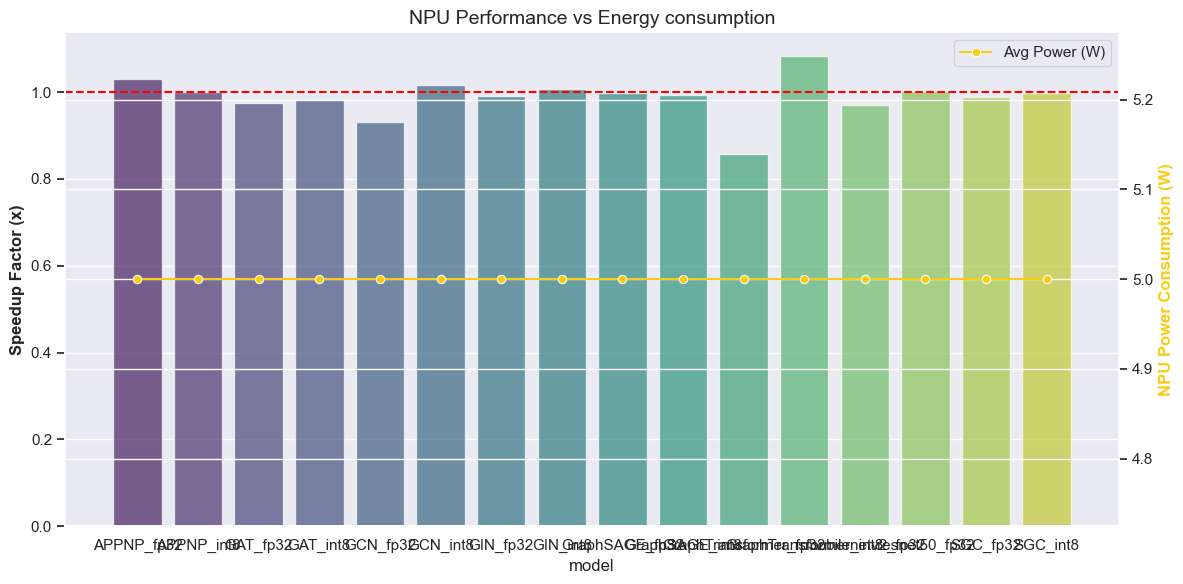

### 📍 ROOFLINE_MODEL.PNG

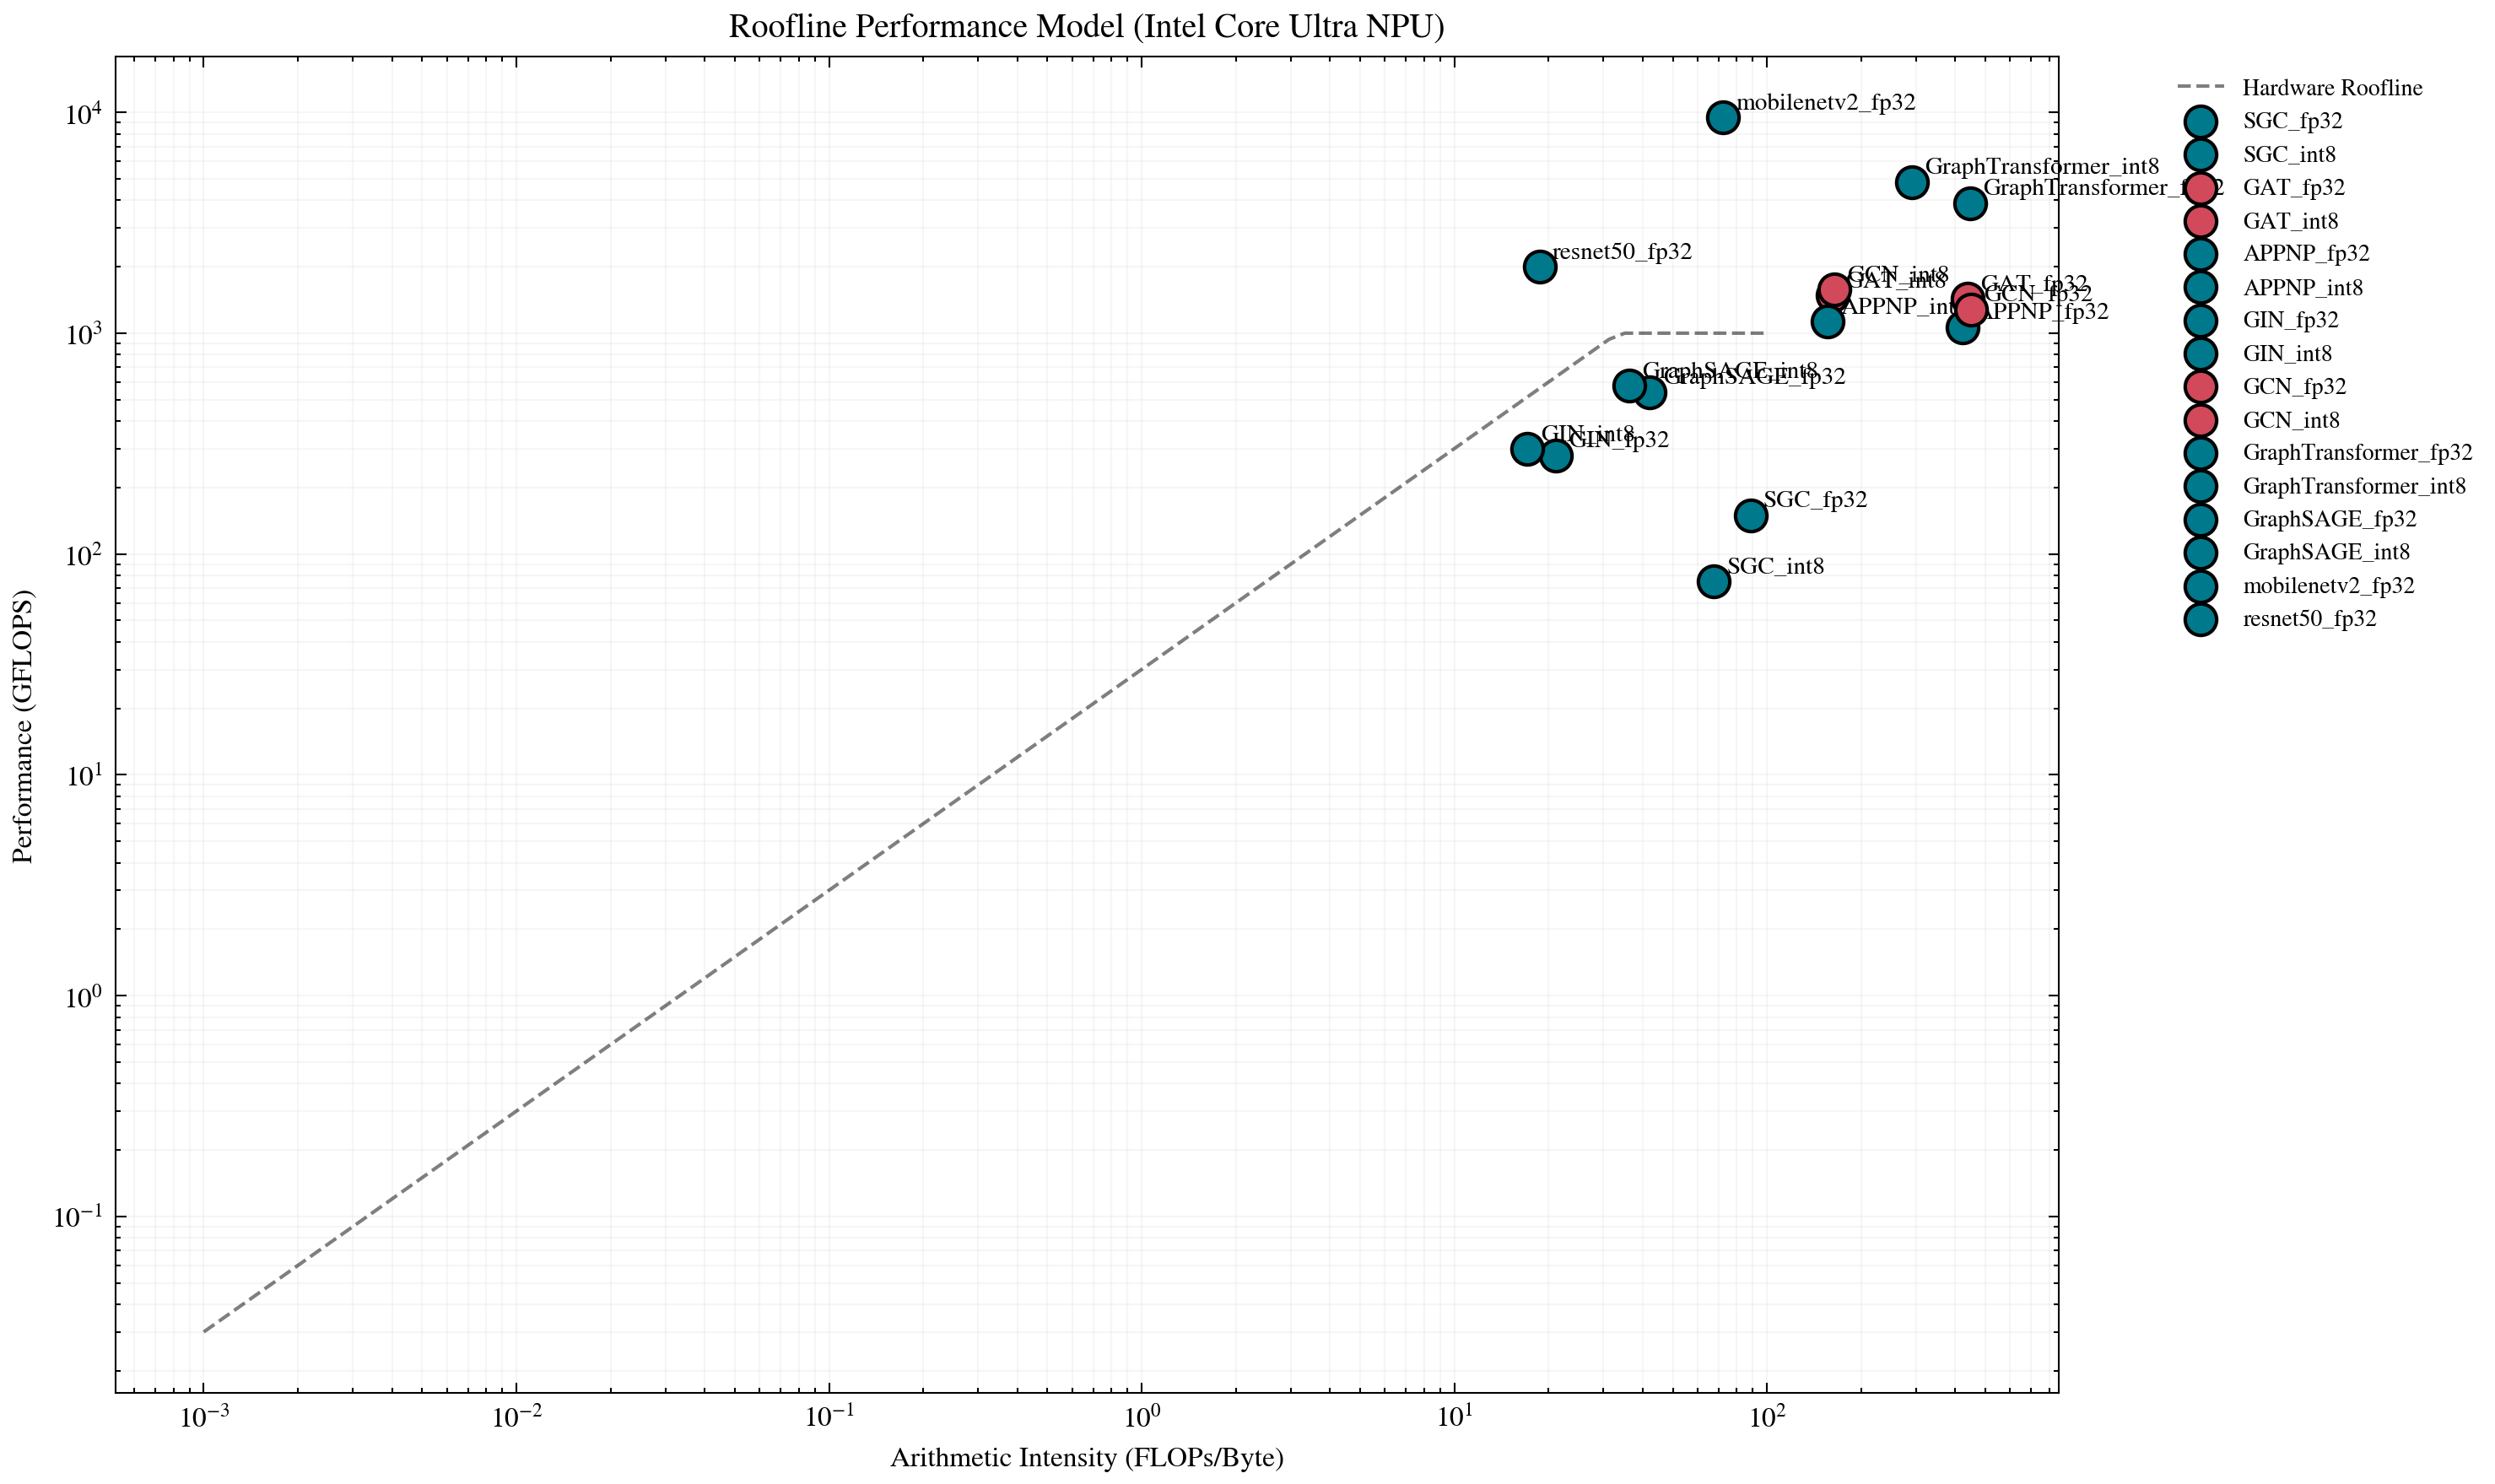

### 📍 LATENCY_STACKED_100PCT.PNG

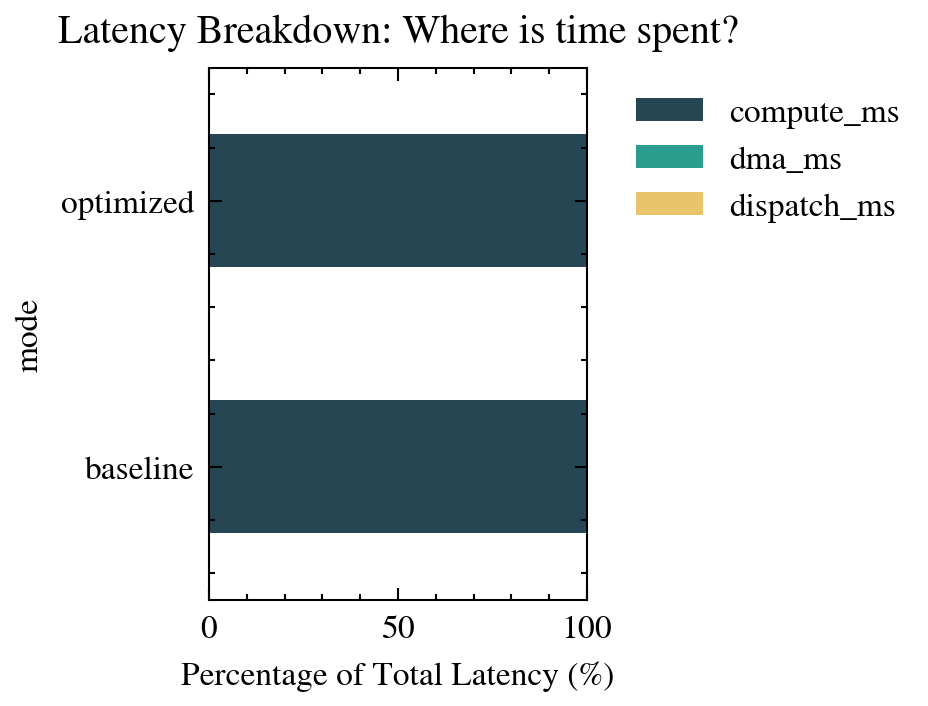

In [12]:
if Path(MATRIX_FILE).exists():
    df = pd.read_csv(MATRIX_FILE)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df, x="model", y="speedup", hue="model", palette="viridis", legend=False, ax=ax1, alpha=0.7)
    ax1.set_ylabel("Speedup Factor (x)", fontweight='bold')
    ax1.axhline(1.0, color="red", ls="--")
    
    if "avg_npu_power_w" in df.columns:
        ax2 = ax1.twinx()
        sns.lineplot(data=df, x="model", y="avg_npu_power_w", color="#facc15", marker="o", ax=ax2, label="Avg Power (W)")
        ax2.set_ylabel("NPU Power Consumption (W)", color="#facc15", fontweight='bold')
    
    plt.title("NPU Performance vs Energy consumption", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # Artifacts
    for img in ["roofline_model.png", "latency_stacked_100pct.png"]:
        if (RESULTS_DIR / img).exists():
            display(Markdown(f"### 📍 {img.upper()}"))
            display(Image(filename=str(RESULTS_DIR / img), width=850))
else:
    print("❌ No data found.")
